# 🛰️ CubeSat EPS — Estimation du SOH avec LSTM

**Stratégie** : le modèle LSTM prédit `delta_SOH` (variation cycle-à-cycle du SOH).
Le SOH est ensuite **reconstruit** en ajoutant la prédiction au dernier SOH connu de chaque fenêtre.

**Prérequis :** `train_normalized.csv` et `test_normalized.csv` disponibles dans Google Drive.

---

| # | Section | Description |
|---|---------|-------------|
| 1 | Imports | Librairies |
| 2 | Chargement | Drive + CSV |
| 3 | Feature engineering | Calcul `delta_SOH` + normalisation |
| 4 | Paramètres | Fenêtre, horizon, etc. |
| 5 | Inspection | Aperçu des données |
| 6 | Séquences | Sliding window |
| 7 | Modèle LSTM | Architecture |
| 8 | Entraînement | Fit + callbacks |
| 9 | Reconstruction SOH | Inverse-transform + cumsum |
| 10 | Évaluation | Métriques sur le SOH reconstruit |
| 11 | Visualisations | Courbes, scatter, résidus |
| 12 | Sauvegarde | Modèle + artefacts |

## 1 — Imports

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, explained_variance_score, max_error
)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

TensorFlow : 2.20.0
GPU        : []


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
# =============================================================================
# scaling.py — Normalisation des données (compatible Colab & VSCode)
# =============================================================================

import os
import joblib
import pandas as pd
from sklearn.preprocessing import MinMaxScaler


BASE_PATH = '/content/drive/MyDrive/Colab Notebooks/dataset_1'

FILE_TRAIN = f"{BASE_PATH}/train.csv"
FILE_TEST  = f"{BASE_PATH}/test.csv"

FILE_TRAIN_NORM = f"{BASE_PATH}/train_norm.csv"
FILE_TEST_NORM  = f"{BASE_PATH}/test_norm.csv"

FILE_FEATURES = f"{BASE_PATH}/features.csv"

OUTPUT_DIR = BASE_PATH
FEATURE_COLS_1 = ['cycle', 'V_mean_V', 'V_spread', 'V_mean_rolling', 'V_mean_lag_1', 'V_min_fade', 'Tavg_C', 'thermal_range', 'delta_T_ambient', 'cold_cycle_count', 'Tavg_rolling', 'eclipse_flag', 'QD_Ah', 'coulombic_eff', 'discharge_C_rate', 'capacity_retention', 'QD_rolling', 'cumul_Ah', 'SOH_lag_1', 'QD_diff']

TARGET_COL = "SOH"
ID_COL = "battery_id"
def run():
    print("=" * 60)
    print("  SCALING — Normalisation des features")
    print("=" * 60)

    # ------------------------------------------------------------------
    # Chargement
    # ------------------------------------------------------------------
    print("\n[1/4] Chargement train/test...")
    train = pd.read_csv(FILE_TRAIN)
    test  = pd.read_csv(FILE_TEST)

    # ------------------------------------------------------------------
    # Séparation X / y
    # ------------------------------------------------------------------
    print("[2/4] Séparation X / y...")
    X_train = train[FEATURE_COLS_1]
    y_train = train[TARGET_COL]

    X_test = test[FEATURE_COLS_1]
    y_test = test[TARGET_COL]

    # ------------------------------------------------------------------
    # Fit scaler UNIQUEMENT sur train
    # ------------------------------------------------------------------
    print("[3/4] Fit MinMaxScaler sur TRAIN uniquement...")
    scaler_X = MinMaxScaler()

    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)

    # ------------------------------------------------------------------
    # Reconstruction DataFrame
    # ------------------------------------------------------------------
    X_train_scaled = pd.DataFrame(X_train_scaled, columns=FEATURE_COLS_1)
    X_test_scaled  = pd.DataFrame(X_test_scaled, columns=FEATURE_COLS_1)

    train_scaled = pd.concat([X_train_scaled, y_train], axis=1)
    test_scaled  = pd.concat([X_test_scaled, y_test], axis=1)

    # ------------------------------------------------------------------
    # Sauvegarde
    # ------------------------------------------------------------------
    print("[4/4] Sauvegarde...")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    train_scaled.to_csv(os.path.join(OUTPUT_DIR, "train_normalized.csv"), index=False)
    test_scaled.to_csv(os.path.join(OUTPUT_DIR, "test_normalized.csv"), index=False)
    OUTPUT = '/content/drive/MyDrive/Colab Notebooks/outputs'
    joblib.dump(scaler_X, os.path.join(OUTPUT, "scaler_X.pkl"))

    print("      → train_scaled.csv")
    print("      → test_scaled.csv")
    print("      → scaler_X.pkl")

    print("\n✅ Scaling terminé\n")

    return scaler_X


if __name__ == "__main__":
    run()

  SCALING — Normalisation des features

[1/4] Chargement train/test...
[2/4] Séparation X / y...
[3/4] Fit MinMaxScaler sur TRAIN uniquement...
[4/4] Sauvegarde...
      → train_scaled.csv
      → test_scaled.csv
      → scaler_X.pkl

✅ Scaling terminé



## 2 — Chargement des données

In [36]:

DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/dataset_1'

train = pd.read_csv(os.path.join(DATA_DIR, 'train_normalized.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'test_normalized.csv'))

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test_df.shape}')
train.head()

Train shape : (5445, 21)
Test  shape : (1362, 21)


,cycle,V_mean_V,V_spread,V_mean_rolling,V_mean_lag_1,V_min_fade,Tavg_C,thermal_range,delta_T_ambient,cold_cycle_count,...,eclipse_flag,QD_Ah,coulombic_eff,discharge_C_rate,capacity_retention,QD_rolling,cumul_Ah,SOH_lag_1,QD_diff,SOH
0,0.000000,0.949284,0.301625,0.974764,0.934426,0.937821,0.765976,0.104147,0.090154,0.000000,...,0.0,1.000000,0.43750,0.713937,1.000000,1.000000,0.000000,1.000000,0.048364,0.999884
1,0.000184,0.962146,0.379663,0.981914,0.949284,0.898157,0.241870,0.920583,0.851170,0.000184,...,1.0,0.999743,0.43750,0.867481,0.999743,0.999868,0.000209,0.999725,0.162178,0.999822
2,0.000367,1.000000,0.264854,0.995494,0.962146,1.000000,0.807546,0.056026,0.118009,0.000367,...,0.0,0.999468,0.75000,0.892365,0.999468,0.999734,0.000419,0.999468,0.046069,0.999756
3,0.000551,0.959799,0.397846,0.995142,1.000000,0.885117,0.194286,0.939935,0.819284,0.000551,...,1.0,0.999204,0.62500,0.773649,0.999204,0.999600,0.000628,0.999193,0.118721,0.999692
4,0.000735,0.988705,0.286117,1.000000,0.959799,0.981613,0.805669,0.072825,0.116752,0.000735,...,0.0,0.998925,0.40625,0.833962,0.998925,0.999465,0.000838,0.998929,0.024160,0.999625


## 3 — Feature Engineering

On calcule `delta_SOH = SOH[t] - SOH[t-1]` comme **cible** du modèle.
On conserve également `soh_raw` (valeurs non-normalisées de SOH dans l'espace des features)
pour la reconstruction finale.

> **Important** : `scaler_y` est ajusté **uniquement** sur le train et appliqué au test
> afin d'éviter tout data-leakage.

In [37]:
# ── 3.1  Calcul de delta_SOH ─────────────────────────────────────────────────
train['delta_SOH'] = train['SOH'].diff()
test_df['delta_SOH']  = test_df['SOH'].diff()

# Supprimer la première ligne (NaN issu du diff)
train = train.dropna(subset=['delta_SOH']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['delta_SOH']).reset_index(drop=True)

# ── 3.2  Normalisation de la cible delta_SOH (fit sur train uniquement) ───────
scaler_y = StandardScaler()
train['delta_SOH_scaled'] = scaler_y.fit_transform(train[['delta_SOH']])
test_df['delta_SOH_scaled']  = scaler_y.transform(test_df[['delta_SOH']])

print('delta_SOH stats (train):')
print(train['delta_SOH'].describe().to_string())
print(f'\nscaler_y  mean={scaler_y.mean_[0]:.6f}  std={scaler_y.scale_[0]:.6f}')

delta_SOH stats (train):
count    5444.000000
mean       -0.000044
std         0.000009
min        -0.000068
25%        -0.000051
50%        -0.000042
75%        -0.000036
max        -0.000029

scaler_y  mean=-0.000044  std=0.000009


## 4 — Paramètres

In [40]:
OUTPUT_DIR  = '/content/drive/MyDrive/Colab Notebooks/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Colonne cible (espace normalisé → sera inversée après prédiction)
TARGET_COL = 'delta_SOH_scaled'

# Sliding window
WINDOW_SIZE = 25   # cycles de contexte
STEP_SIZE   = 6   # pas du sliding window
HORIZON     = 100    # prédire delta_SOH à t+1

overlap = (WINDOW_SIZE - STEP_SIZE) / WINDOW_SIZE * 100
print(f'WINDOW_SIZE = {WINDOW_SIZE}  |  STEP_SIZE = {STEP_SIZE}  |  HORIZON = {HORIZON}')
print(f'Overlap     = {overlap:.1f} %')
print('Paramètres chargés ✅')

WINDOW_SIZE = 25  |  STEP_SIZE = 6  |  HORIZON = 100
Overlap     = 76.0 %
Paramètres chargés ✅


## 5 — Inspection des données

In [41]:
# Colonnes features = tout sauf les colonnes cible/auxiliaires
EXCLUDE_COLS  = ['SOH', 'delta_SOH', 'delta_SOH_scaled']
FEATURE_COLS  = [c for c in train.columns if c not in EXCLUDE_COLS]

print(f'Train : {train.shape}  |  Test : {test_df.shape}')
print(f'\nFeatures ({len(FEATURE_COLS)}) :')
print(FEATURE_COLS)
print(f'\nCible (espace normalisé) : {TARGET_COL}')

# Vérification : pas de NaN dans les features
assert train[FEATURE_COLS].isna().sum().sum() == 0, 'NaN dans features train !'
assert test_df[FEATURE_COLS].isna().sum().sum()  == 0, 'NaN dans features test  !'
print('\n✅ Aucun NaN détecté dans les features')

Train : (5444, 23)  |  Test : (1361, 23)

Features (20) :
['cycle', 'V_mean_V', 'V_spread', 'V_mean_rolling', 'V_mean_lag_1', 'V_min_fade', 'Tavg_C', 'thermal_range', 'delta_T_ambient', 'cold_cycle_count', 'Tavg_rolling', 'eclipse_flag', 'QD_Ah', 'coulombic_eff', 'discharge_C_rate', 'capacity_retention', 'QD_rolling', 'cumul_Ah', 'SOH_lag_1', 'QD_diff']

Cible (espace normalisé) : delta_SOH_scaled

✅ Aucun NaN détecté dans les features


In [42]:
train_ratio = 0.8
n = len(train)
n_train = int(n * train_ratio)

train_df = train.iloc[:n_train]
val   = train.iloc[n_train:]

print(f"Train: {len(train_df)} | Val: {len(val)}")

Train: 4355 | Val: 1089


In [43]:
train_df.head()

,cycle,V_mean_V,V_spread,V_mean_rolling,V_mean_lag_1,V_min_fade,Tavg_C,thermal_range,delta_T_ambient,cold_cycle_count,...,coulombic_eff,discharge_C_rate,capacity_retention,QD_rolling,cumul_Ah,SOH_lag_1,QD_diff,SOH,delta_SOH,delta_SOH_scaled
0,0.000184,0.962146,0.379663,0.981914,0.949284,0.898157,0.241870,0.920583,0.851170,0.000184,...,0.43750,0.867481,0.999743,0.999868,0.000209,0.999725,0.162178,0.999822,-0.000062,-1.879792
1,0.000367,1.000000,0.264854,0.995494,0.962146,1.000000,0.807546,0.056026,0.118009,0.000367,...,0.75000,0.892365,0.999468,0.999734,0.000419,0.999468,0.046069,0.999756,-0.000066,-2.364290
2,0.000551,0.959799,0.397846,0.995142,1.000000,0.885117,0.194286,0.939935,0.819284,0.000551,...,0.62500,0.773649,0.999204,0.999600,0.000628,0.999193,0.118721,0.999692,-0.000064,-2.061138
3,0.000735,0.988705,0.286117,1.000000,0.959799,0.981613,0.805669,0.072825,0.116752,0.000735,...,0.40625,0.833962,0.998925,0.999465,0.000838,0.998929,0.024160,0.999625,-0.000067,-2.455707
4,0.000918,0.903725,0.389479,0.990636,0.988705,0.837515,0.084367,0.975322,0.745627,0.000918,...,0.65625,0.652572,0.998679,0.999333,0.001047,0.998650,0.227045,0.999565,-0.000059,-1.609129


## 6 — Construction des séquences (Sliding Window)

La fonction retourne également `last_soh` : le SOH **non-normalisé** du dernier
cycle de chaque fenêtre — nécessaire pour reconstruire SOH = last_soh + Δ_pred.

In [44]:
def build_sequences(df, window, step, horizon, feature_cols, target_col):
    features  = df[feature_cols].values
    target    = df[target_col].values
    soh_raw   = df['SOH'].values

    n_total   = len(df)
    max_start = n_total - window - horizon + 1

    if max_start <= 0:
        raise ValueError(
            f'Pas assez de données ({n_total}) pour window={window} + horizon={horizon}'
        )

    X_list, y_list, last_soh_list, true_soh_list = [], [], [], []

    for start in range(0, max_start, step):
        end  = start + window
        pred = end + horizon - 1

        X_list.append(features[start:end])
        y_list.append(target[pred])
        last_soh_list.append(soh_raw[end - 1])
        true_soh_list.append(soh_raw[pred])

    X        = np.array(X_list,        dtype=np.float32)
    y_scaled = np.array(y_list,        dtype=np.float32)
    last_soh = np.array(last_soh_list, dtype=np.float64)
    true_soh = np.array(true_soh_list, dtype=np.float64)

    print(f'  {n_total:,} lignes → {len(X_list):,} séquences | X={X.shape}')
    return X, y_scaled, last_soh, true_soh


# =========================
# 3. CONSTRUCTION
# =========================

print('[Train]')
X_train, y_train_scaled, last_soh_train, true_soh_train = build_sequences(
    train_df, WINDOW_SIZE, STEP_SIZE, HORIZON, FEATURE_COLS, TARGET_COL
)

print('[Validation]')
X_val, y_val_scaled, last_soh_val, true_soh_val = build_sequences(
    val, WINDOW_SIZE, STEP_SIZE, HORIZON, FEATURE_COLS, TARGET_COL
)

print('[Test]')
X_test, y_test_scaled, last_soh_test, true_soh_test = build_sequences(
    test_df, WINDOW_SIZE, STEP_SIZE, HORIZON, FEATURE_COLS, TARGET_COL
)

assert not np.any(np.isnan(X_train)), 'NaN dans X_train !'
assert not np.any(np.isnan(X_val)),   'NaN dans X_val !'
assert not np.any(np.isnan(X_test)),  'NaN dans X_test !'

assert not np.any(np.isnan(y_train_scaled)), 'NaN dans y_train !'
assert not np.any(np.isnan(y_val_scaled)),   'NaN dans y_val !'
assert not np.any(np.isnan(y_test_scaled)),  'NaN dans y_test !'


print(f'\ndelta_SOH train — min={y_train_scaled.min():.3f} max={y_train_scaled.max():.3f}')
print(f'delta_SOH val   — min={y_val_scaled.min():.3f} max={y_val_scaled.max():.3f}')
print(f'delta_SOH test  — min={y_test_scaled.min():.3f} max={y_test_scaled.max():.3f}')

print(f'\nSOH train — min={true_soh_train.min():.4f} max={true_soh_train.max():.4f}')
print(f'SOH val   — min={true_soh_val.min():.4f} max={true_soh_val.max():.4f}')
print(f'SOH test  — min={true_soh_test.min():.4f} max={true_soh_test.max():.4f}')

print('\n✅ Séquences train / val / test prêtes')

[Train]
  4,355 lignes → 706 séquences | X=(706, 25, 20)
[Validation]
  1,089 lignes → 161 séquences | X=(161, 25, 20)
[Test]
  1,361 lignes → 207 séquences | X=(207, 25, 20)

delta_SOH train — min=-1.959 max=1.600
delta_SOH val   — min=-1.891 max=1.008
delta_SOH test  — min=-1.784 max=0.885

SOH train — min=0.8035 max=0.9931
SOH val   — min=0.7589 max=0.7990
SOH test  — min=0.7000 max=0.7529

✅ Séquences train / val / test prêtes


## 7 — Architecture du modèle LSTM

In [45]:
def build_lstm_model(window_size, n_features, lr=1e-3, l2_reg=1e-4):
    model = Sequential([
        LSTM(32,
             return_sequences=True,
             kernel_regularizer=None,
             input_shape=(window_size, n_features)),
        BatchNormalization(),

        LSTM(16,
             return_sequences=False,
             kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),

        Dense(16, activation='relu', kernel_regularizer=l2(l2_reg)),
        Dropout(0.3),

        Dense(1, activation='linear', name='delta_SOH_output')
    ], name='LSTM_SOH_Estimator')

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model


model = build_lstm_model(X_train.shape[1], X_train.shape[2])
model.summary()

Model: "LSTM_SOH_Estimator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 25, 32)         │         6,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ delta_SOH_output (Dense)        │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,401 (40.63 KB)

 Trainable params: 10,305 (40.25 KB)

 Non-trainable params: 96 (384.00 B)

## 8 — Entraînement

In [46]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    ),
]

history = model.fit(
    X_train, y_train_scaled,
    validation_data=(X_val, y_val_scaled),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print('\n✅ Entraînement terminé')

Epoch 1/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - loss: 1.5000 - mae: 1.0170 - val_loss: 0.6559 - val_mae: 0.6993 - learning_rate: 0.0010
Epoch 2/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.9380 - mae: 0.8099 - val_loss: 0.6293 - val_mae: 0.6741 - learning_rate: 0.0010
Epoch 3/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.9126 - mae: 0.8013 - val_loss: 0.6009 - val_mae: 0.6390 - learning_rate: 0.0010
Epoch 4/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.8676 - mae: 0.7742 - val_loss: 0.5990 - val_mae: 0.6286 - learning_rate: 0.0010
Epoch 5/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.8451 - mae: 0.7623 - val_loss: 0.5957 - val_mae: 0.6264 - learning_rate: 0.0010
Epoch 6/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.8035 - mae: 0.7373 - val_loss: 0.5975 - val_mae: 0.6198 - learning_rate: 0.0010
Epoch 7/200
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.7976 - mae: 0.7334 - val_loss: 0.5947 - val_mae: 0.6091 - learning_rate: 0.0010
Epoch 

## 9 — Reconstruction du SOH

Le LSTM prédit `delta_SOH` dans l'espace **normalisé**.
La reconstruction se fait en deux étapes :

1. **Inverse-transform** : `delta_pred = scaler_y.inverse_transform(y_pred_scaled)` → espace réel
2. **Cumul** : `SOH_pred[t] = last_soh[t] + delta_pred[t]`
   où `last_soh[t]` est le dernier SOH **connu** dans la fenêtre (issu des données de test).

La même logique s'applique à la vérité terrain pour aligner les deux séries.

In [47]:
# ── 9.1  Prédictions brutes (espace normalisé delta_SOH) ────────────────────
y_pred_scaled = model.predict(X_test, verbose=0).flatten()

# ── 9.2  Inverse-transform → espace réel delta_SOH ─────────────────────────
delta_soh_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).flatten()

delta_soh_true = scaler_y.inverse_transform(
    y_test_scaled.reshape(-1, 1)
).flatten()

# ── 9.3  Reconstruction SOH = dernier SOH connu + delta ─────────────────────
#   last_soh_test[i]  : SOH au cycle window-1 de la i-ème séquence (connu)
#   true_soh_test[i]  : SOH au cycle window+horizon-1 (vérité terrain)
soh_pred = last_soh_test + delta_soh_pred   # SOH prédit
soh_true = true_soh_test                    # SOH réel (directement stocké)

# ── 9.4  Vérification de cohérence ─────────────────────────────────────────
soh_true_check = last_soh_test + delta_soh_true  # doit ≈ true_soh_test
recon_error = np.abs(soh_true_check - soh_true).max()
print(f'Erreur de reconstruction vérité terrain (max) : {recon_error:.2e}  (doit être ~0)')

print(f'\nSOH prédit — min={soh_pred.min():.4f}  max={soh_pred.max():.4f}  mean={soh_pred.mean():.4f}')
print(f'SOH réel   — min={soh_true.min():.4f}  max={soh_true.max():.4f}  mean={soh_true.mean():.4f}')
print('\n✅ Reconstruction SOH terminée')

Erreur de reconstruction vérité terrain (max) : 5.22e-03  (doit être ~0)

SOH prédit — min=0.7044  max=0.7578  mean=0.7309
SOH réel   — min=0.7000  max=0.7529  mean=0.7267

✅ Reconstruction SOH terminée


## 10 — Évaluation — Métriques sur le SOH reconstruit

> Toutes les métriques sont calculées dans l'**espace SOH réel** (non-normalisé),
> pas dans l'espace delta_SOH normalisé.

In [48]:
mse   = mean_squared_error(soh_true, soh_pred)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(soh_true, soh_pred)
r2    = r2_score(soh_true, soh_pred)
evs   = explained_variance_score(soh_true, soh_pred)
me    = max_error(soh_true, soh_pred)
medae = np.median(np.abs(soh_true - soh_pred))

mask  = soh_true != 0
mape  = np.mean(np.abs((soh_true[mask] - soh_pred[mask]) / soh_true[mask])) * 100
smape = np.mean(
    2 * np.abs(soh_true - soh_pred) / (np.abs(soh_true) + np.abs(soh_pred) + 1e-8)
) * 100

sep = '=' * 52
print(sep)
print('  ÉVALUATION — SOH reconstruit (espace réel)')
print(sep)
print(f'  MAE              : {mae:.6f}')
print(f'  MSE              : {mse:.6f}')
print(f'  RMSE             : {rmse:.6f}')
print(f'  MAPE             : {mape:.4f} %')
print(f'  SMAPE            : {smape:.4f} %')
print(f'  Median Abs Error : {medae:.6f}')
print(f'  Max Error        : {me:.6f}')
print(f'  R²               : {r2:.6f}')
print(f'  Explained Var    : {evs:.6f}')
print(sep)

  ÉVALUATION — SOH reconstruit (espace réel)
  MAE              : 0.004276
  MSE              : 0.000018
  RMSE             : 0.004293
  MAPE             : 0.5888 %
  SMAPE            : 0.5870 %
  Median Abs Error : 0.004230
  Max Error        : 0.005224
  R²               : 0.918848
  Explained Var    : 0.999361


## 11 — Visualisations

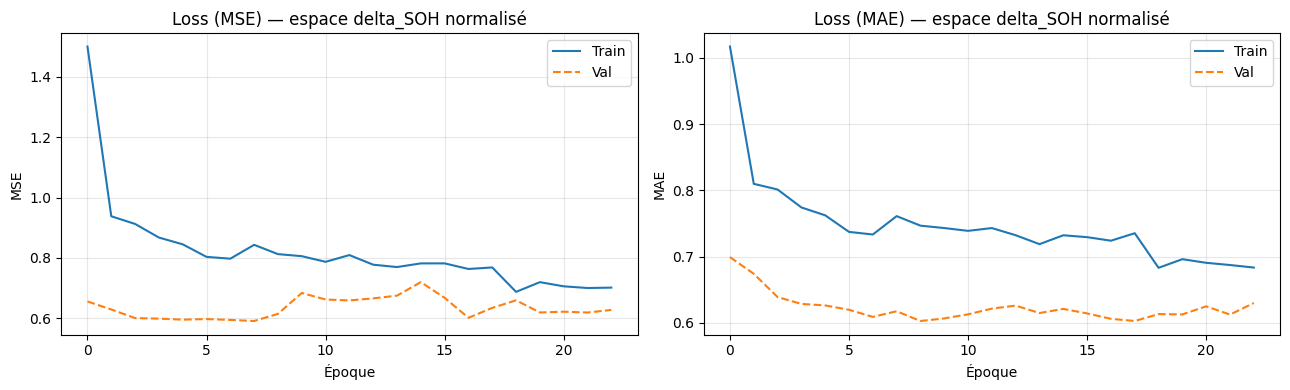

✅ loss_curves.png sauvegardé


In [49]:
# ── 11.1  Courbes de perte ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history.history['loss'],     label='Train', linewidth=1.5)
axes[0].plot(history.history['val_loss'], label='Val',   linewidth=1.5, linestyle='--')
axes[0].set(xlabel='Époque', ylabel='MSE', title='Loss (MSE) — espace delta_SOH normalisé')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['mae'],     label='Train', linewidth=1.5)
axes[1].plot(history.history['val_mae'], label='Val',   linewidth=1.5, linestyle='--')
axes[1].set(xlabel='Époque', ylabel='MAE', title='Loss (MAE) — espace delta_SOH normalisé')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ loss_curves.png sauvegardé')

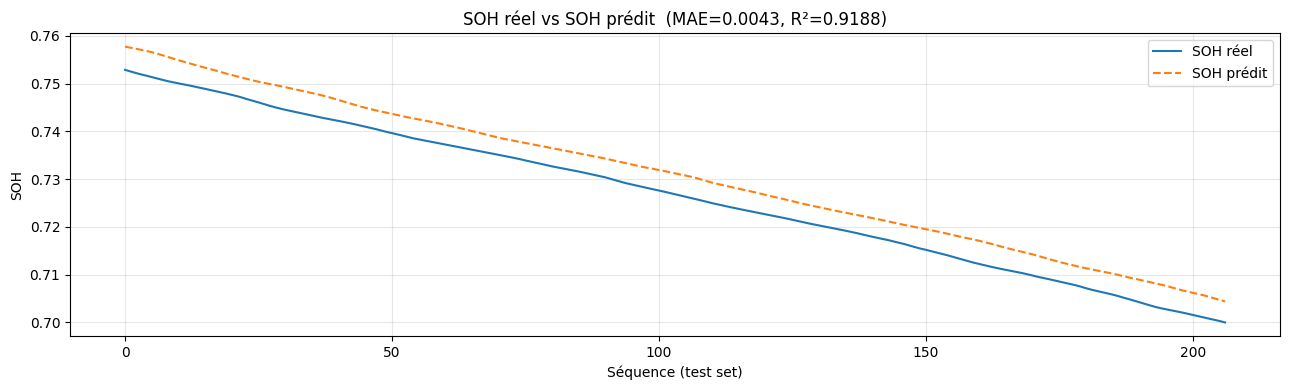

✅ soh_pred_vs_true.png sauvegardé


In [50]:
# ── 11.2  SOH réel vs SOH prédit (série temporelle) ─────────────────────────
n_show = min(500, len(soh_pred))

plt.figure(figsize=(13, 4))
plt.plot(soh_true[:n_show], label='SOH réel',  linewidth=1.5)
plt.plot(soh_pred[:n_show], label='SOH prédit', linewidth=1.5, linestyle='--')
plt.xlabel('Séquence (test set)')
plt.ylabel('SOH')
plt.title(f'SOH réel vs SOH prédit  (MAE={mae:.4f}, R²={r2:.4f})')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'soh_pred_vs_true.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ soh_pred_vs_true.png sauvegardé')

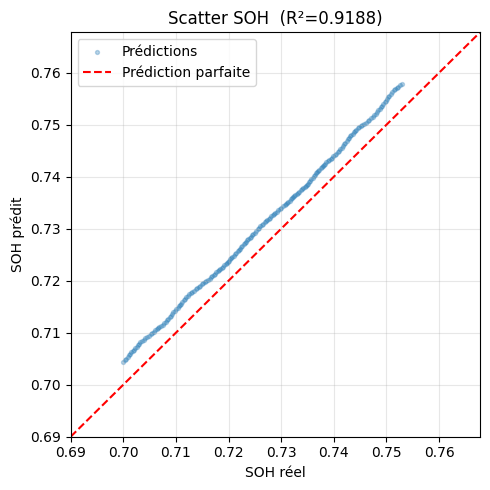

✅ scatter_soh.png sauvegardé


In [51]:
# ── 11.3  Scatter : SOH réel vs SOH prédit ───────────────────────────────────
plt.figure(figsize=(5, 5))
plt.scatter(soh_true, soh_pred, alpha=0.3, s=8, label='Prédictions')

lims = [
    min(soh_true.min(), soh_pred.min()) - 0.01,
    max(soh_true.max(), soh_pred.max()) + 0.01
]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Prédiction parfaite')
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('SOH réel')
plt.ylabel('SOH prédit')
plt.title(f'Scatter SOH  (R²={r2:.4f})')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'scatter_soh.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✅ scatter_soh.png sauvegardé')

In [52]:
import joblib

# Modèle Keras
model_path = os.path.join(OUTPUT_DIR, 'cubesat_soh_lstm_model.h5')
model.save(model_path)
print(f'✅ Modèle sauvegardé     → {model_path}')

# Scaler de la cible (nécessaire pour l'inférence)
scaler_path = os.path.join(OUTPUT_DIR, 'scaler_y.pkl')
joblib.dump(scaler_y, scaler_path)
print(f'✅ scaler_y sauvegardé   → {scaler_path}')

# Métriques
metrics_dict = {
    'MAE': mae, 'MSE': mse, 'RMSE': rmse,
    'MAPE': mape, 'SMAPE': smape,
    'MedianAE': medae, 'MaxError': me,
    'R2': r2, 'ExplainedVariance': evs
}
metrics_df = pd.DataFrame([metrics_dict])
metrics_path = os.path.join(OUTPUT_DIR, 'metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f'✅ Métriques sauvegardées → {metrics_path}')

print(f'\nContenu de {OUTPUT_DIR}/')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f}')

✅ Modèle sauvegardé     → /content/drive/MyDrive/Colab Notebooks/outputs/cubesat_soh_lstm_model.h5
✅ scaler_y sauvegardé   → /content/drive/MyDrive/Colab Notebooks/outputs/scaler_y.pkl
✅ Métriques sauvegardées → /content/drive/MyDrive/Colab Notebooks/outputs/metrics.csv

Contenu de /content/drive/MyDrive/Colab Notebooks/outputs/
  cubesat_soh_lstm_model.h5
  loss_curves.png
  metrics.csv
  scaler_X.joblib
  scaler_X.pkl
  scaler_y.pkl
  scatter_soh.png
  soh_pred_vs_true.png
